In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1. import database / data

In [5]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """ 
        SELECT name
        FROM sqlite_master
        WHERE type='table'
"""

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Create dataframe: df_{table_name}")

# Close connection
conn.close()

Create dataframe: df_db_customer
Create dataframe: df_db_subscription
Create dataframe: df_db_support


In [6]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [ ]:
#2. Data Cleaning

In [10]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [8]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [11]:
#a. rename col name to customer_name 
#b. drop columns - interest and pincode
#c. change data type - dob
#d. data standardization - Gender
# e. fix missing values - country

In [22]:
# rename col name to customer_name 

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [27]:
#b. drop columns - interest and pincode using Index value
# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)

#b. drop columns - interest and pincode using Column Name
df_db_customer.drop(columns = ['interests' , 'pincode'], inplace = True)

In [31]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [30]:
#c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [34]:
#d. data standardization - Gender 

#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [36]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [44]:
#df_db_customer['country'].fillna() -> to fill in values 

#df_db_customer[['country' , 'state']]

# Create a state-to-country mapping and use it to fill missing country values based on the customer's state.
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [45]:
 df_db_customer[['country' , 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [48]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [47]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [51]:
date_col = ['subscription_start_date' , 'renewal_date' , 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [52]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [53]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [55]:
df_db_support.drop(columns=['col_1' , 'comment'], inplace=True)

In [56]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [58]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [59]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [ ]:
# 3. Feature Engineering and and Data Analysis

In [63]:
# create a new column using existing column - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1,0)

In [62]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [81]:
# first fix support table duplicates and then merge

df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid' , how='left')
    .merge(df_db_support, on = 'customerid' , how='left'))

In [68]:
df_db_subscription.shape

(21, 12)

In [67]:
# to get rows and cols of the data frame
df.shape

(23, 20)

In [71]:
df_db_subscription['customerid'].nunique()

21

In [72]:
df_db_customer['customerid'].nunique()

21

In [73]:
df_db_support['customerid'].nunique()

7

In [74]:
df_db_support['customerid'].size

9

In [76]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [77]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [79]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [80]:
df_db_support['customerid'].size

7

In [83]:
# merge df 

df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid' , how='left')
    .merge(df_db_support, on = 'customerid' , how='left'))

In [84]:
df.shape

(21, 21)

In [85]:
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
# Data Analysis

In [ ]:
#1. Churn Rate

In [86]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [89]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [91]:
#2. Retention Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [95]:
#3 Churn by Plan Type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name= 'churn_rate_pct')

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [96]:
#4 Churn by state

churn_by_state = df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name= 'churn_rate_pct')

print(churn_by_state)

           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [97]:
#4 Churn by subscription type

churn_by_sub_type = df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name= 'churn_rate_pct')

print(churn_by_sub_type)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           16.67
2          Refferal           83.33


In [99]:
#5 ARPU- Avg Revenue per user

arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [107]:
#6 Avg Customer Tenure
# count of days users have used our service : cancellation done else current date

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days)= ", round(avg_tenure),0)

Avg Tenure (Days)=  1514 0


In [111]:
#7. Revenue at risk - revenue from churn users

revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs K)= ",revenue_at_risk)

Revenue at Risk (Rs K)=  73.94


In [115]:
#8. Escalation Rate 

escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate", round(escalation_rate, 2), "%")

Escalation Rate 19.05 %


In [117]:
#9 Avg Complaint per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaint per user = ", round (avg_complaints, 2))

Avg Complaint per user =  0.43


In [130]:
df = pd.read_csv('exported_churn_data.csv')

In [131]:
df['escalations'].value_counts(dropna=False)

escalations
NaN    14
Y       4
N       3
Name: count, dtype: int64

In [132]:
# Encode Y = 1, N = 0, and keep missing values as NaN
df['escalations'] = df['escalations'].map({'Y': 1, 'N': 0})

In [133]:
df['escalations'].value_counts(dropna=False)

escalations
NaN    14
1.0     4
0.0     3
Name: count, dtype: int64

In [134]:
#10 Correaltion Escalation vs Churn
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])

print("Correlation between Escalation and Churn Flag =", round(correlation, 2))

Correlation between Escalation and Churn Flag = 0.47


In [135]:
#11. Create a column using exisiting column - Churn Rate

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70), 
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [137]:
df[['churn_risk', 'churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [138]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='str')

In [ ]:
#4. Data Visualization using matplot lib

In [142]:
date_col = ['subscription_start_date' , 'renewal_date' , 'cancellation_date', 'complaint_date',]

df[date_col] = df[date_col].apply(pd.to_datetime)

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn_flag               21 non-null     int64         
 12  customer_name            21 non-null     str     

In [145]:
df_visual = df.copy()

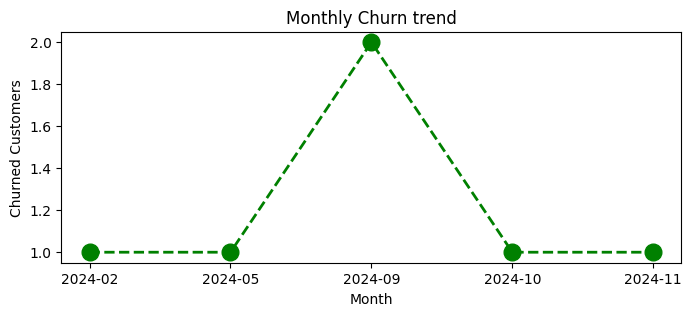

In [151]:
# 4.1 Monthly Churn Trend [Time Series KPI]

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = (
    df_visual[df_visual['churn_flag'] == 1]
    .groupby('cancellation_month')
    .size()
)

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green' , marker='o' , linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

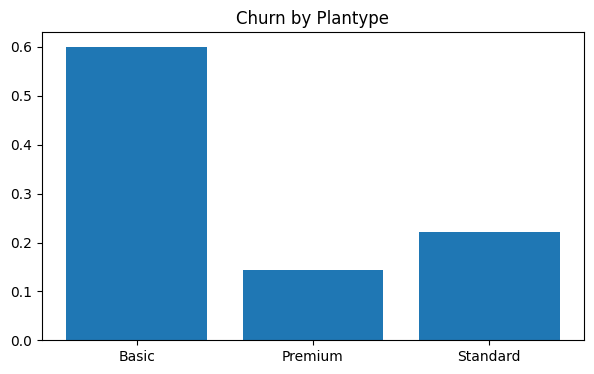

In [155]:
#4.2 Churn by Plantype
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.title('Churn by Plantype')
plt.show()

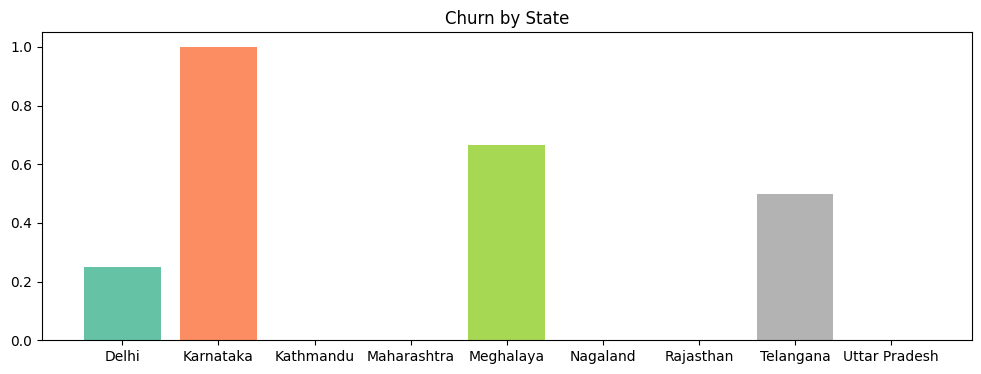

In [158]:
#4.3 Churn by State

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.title('Churn by State')
plt.show()

In [ ]:
#Visualization using Seaborn

In [159]:
# ecoding str to num so that we can find corr b/w features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'cancellation_month'],
      dtype='str')

In [164]:
#incorrect method of encoding as numbers are not assigned based on priority

df_encoded = df_visual [['plan_type' , 'contract_type' , 'churn_score' , 'churn_flag' , 'churn_risk' , 'escalations']]

categorical_cols = ['plan_type' , 'contract_type' , 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

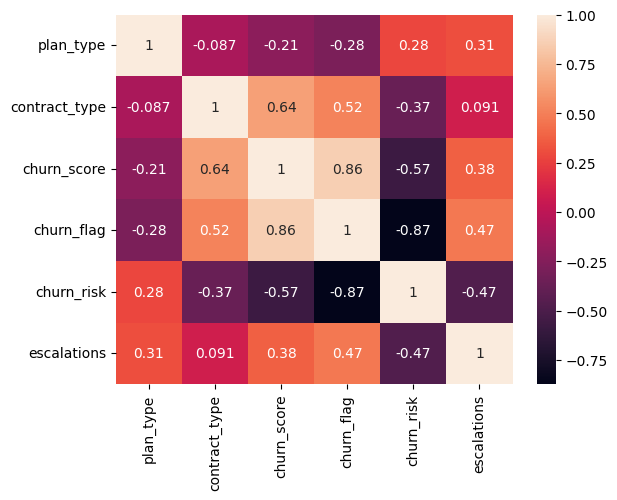

In [162]:
#Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [169]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

In [174]:
#correct method of encoding as numbers are not assigned based on priority

df_encoded = df_visual [['plan_type' , 'contract_type' , 'churn_score' , 'churn_flag' , 'churn_risk' , 'escalations']]

order_mapping = {
    'plan_type': ['Basic' , 'Standard' , 'Premium'] ,
    'contract_type': ['Monthly' , 'Annual'],
    'churn_risk': ['low' , 'med' , 'high']
    }

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [175]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,NaN
1,2,1,91,1,2,1.0
2,0,0,34,0,0,NaN
3,2,1,8,0,0,NaN
4,1,0,88,1,2,1.0


<Axes: >

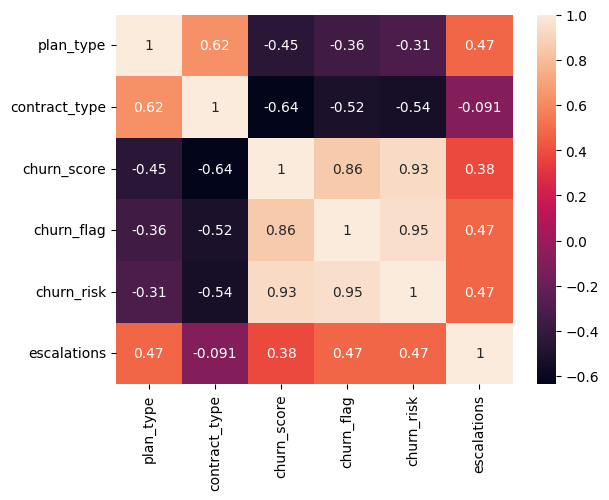

In [176]:
#Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

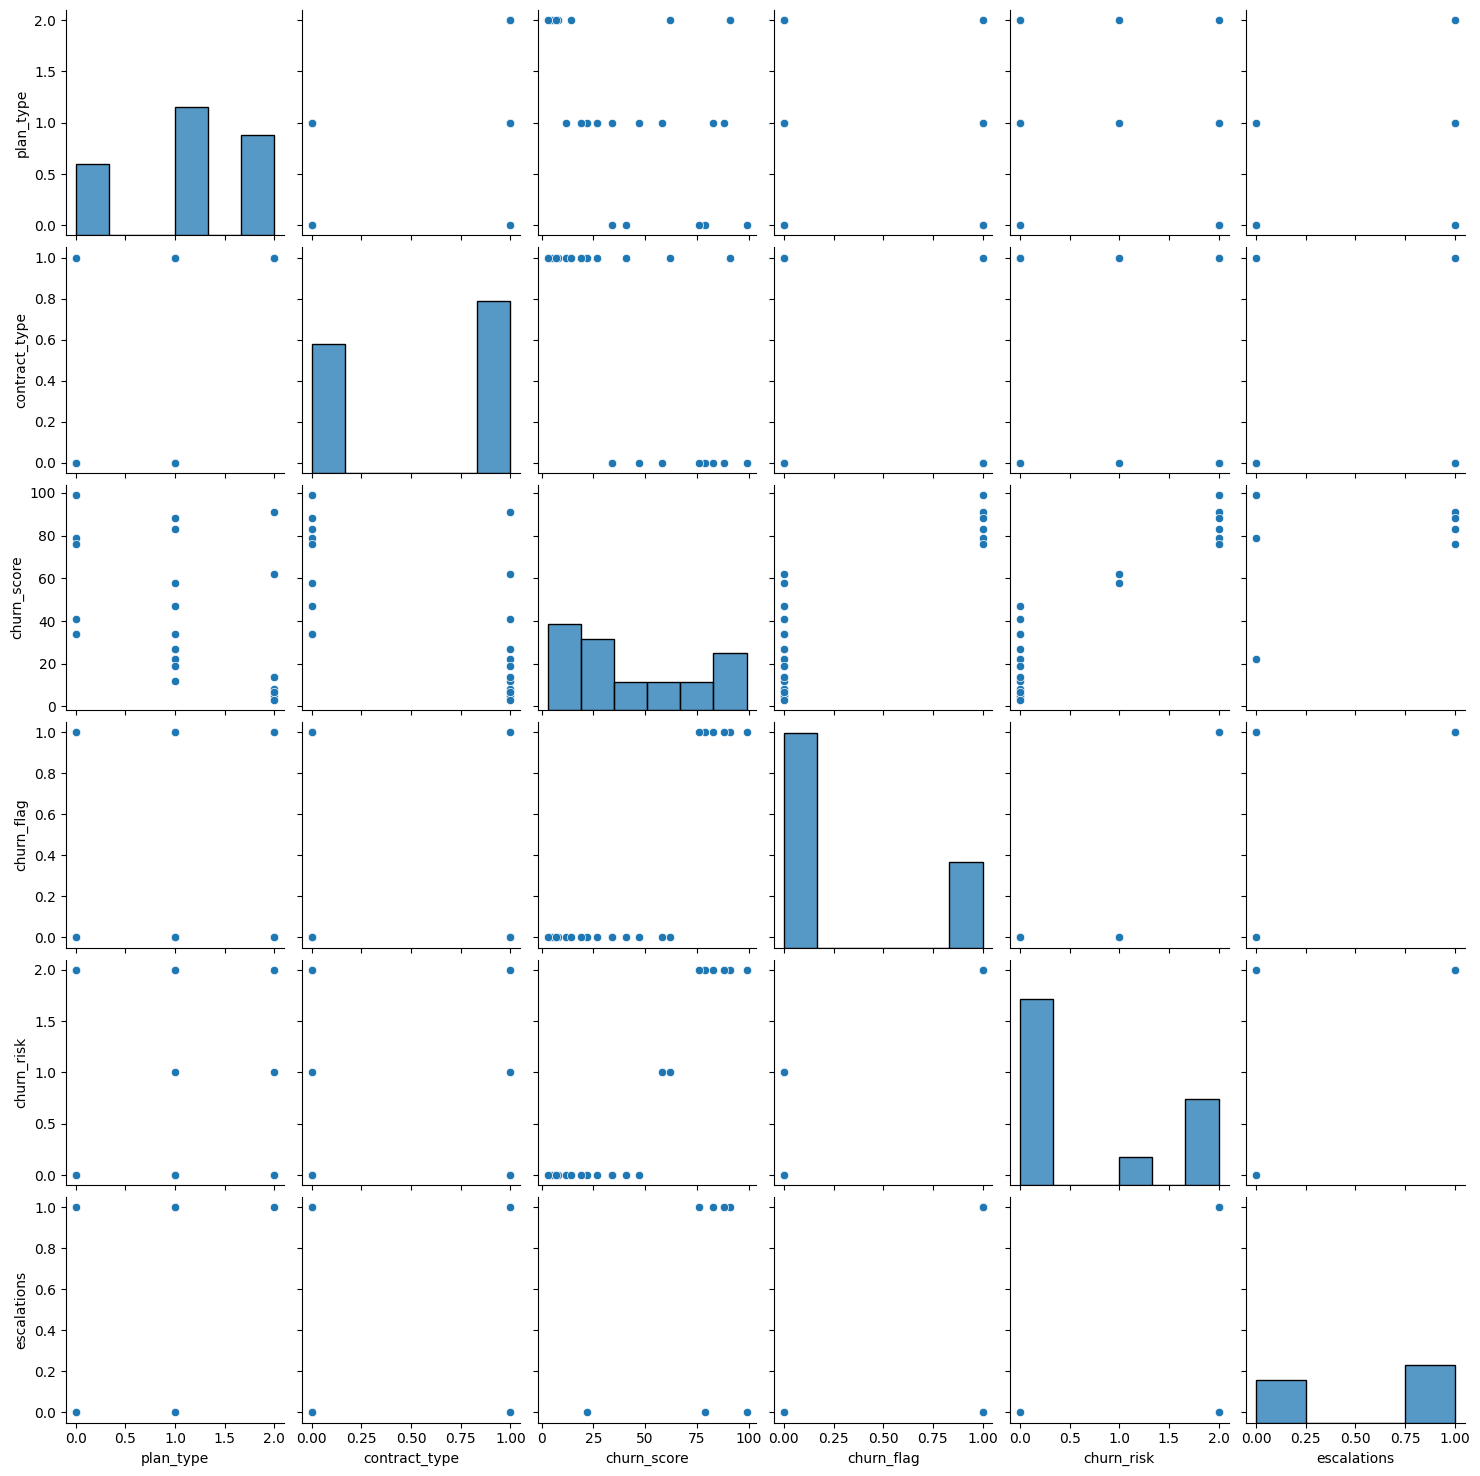

In [178]:
# Pairplot- relationship in a dataset
sns.pairplot(df_encoded)

In [179]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'cancellation_month'],
      dtype='str')

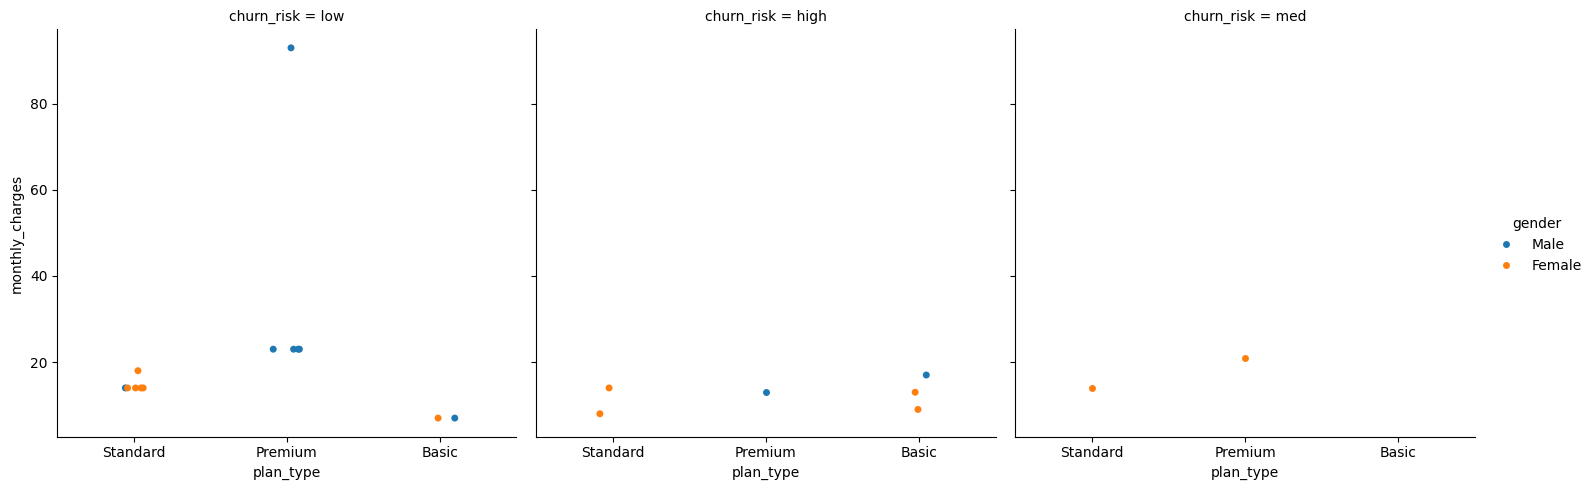

In [181]:
# catplot / Facegrid plot - multi dimension comparison

sns.catplot(
    data = df_visual,
    x = 'plan_type', 
    y = 'monthly_charges',
    hue = 'gender',
    col = 'churn_risk'  
)

In [ ]:
# Pivot table

In [184]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [185]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'cancellation_month'],
      dtype='str')

In [186]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges' , 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges': 'sum',
        'customerid': 'nunique' ,
        'churn_flag': 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91
